# VAR forecasting with Impulso

A vector autoregression models several series jointly: each series depends on the past of
every series, and the shocks are correlated. This notebook fits a VAR(2) to the quarterly
growth rates of US real GDP, consumption and investment — the same series as the
[numpyro-forecast VAR example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/var.html)
— and scores the density forecasts with `backtest`.

The lag recursion, Minnesota prior and density forecast live in
[Impulso](https://impulso.quantclimate.com/). pymc-forecast does not grow a VAR
implementation for this example, and Impulso is not a core dependency: it is installed with
the `notebooks` and `docs` groups. Identification and impulse responses stay in Impulso;
they are not part of the forecast score.

In [1]:
import logging
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from impulso import VAR, VARData
from impulso.priors import MinnesotaPrior
from impulso.samplers import NUTSSampler
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from pymc_forecast import (
    DEFAULT_METRICS,
    backtest,
    eval_crps,
    evaluate_forecast,
    null_covariates,
    prediction_samples,
    results_to_dataframe,
    thin_draws,
)
from pymc_forecast.datasets import load_us_macro
from pymc_forecast.metrics import Metric

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)
# Impulso 0.1.3 drives pm.sample through arguments that PyMC 6 deprecates.
for message in ("`nuts_sampler_kwargs` is deprecated", "Passing `log_likelihood` via"):
    warnings.filterwarnings("ignore", message=message, category=FutureWarning)

SEED = 2026
HOLDOUT = 8  # quarters per test window

# CI executes every example notebook end-to-end with reduced settings.
SMOKE_TEST = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
DRAWS, TUNE, CHAINS = (25, 25, 1) if SMOKE_TEST else (1000, 1000, 4)
NUM_SAMPLES = DRAWS * CHAINS
FOLDS = 1 if SMOKE_TEST else 4

## Quarterly growth rates

`load_us_macro` returns the quarterly levels of the three series (the `statsmodels`
macro panel, 1959Q1–2009Q3). The VAR is fit to approximate quarterly percent growth,
`100 * Δ log`, not to the levels. Investment is the volatile series; Impulso's Minnesota
prior rescales cross-lags by each series' AR(1) residual scale, so the columns do not need
to be standardised first.

In [2]:
growth = (100 * np.log(load_us_macro())).diff("time").rename("growth")
growth.sizes

Frozen({'time': 202, 'series': 3})

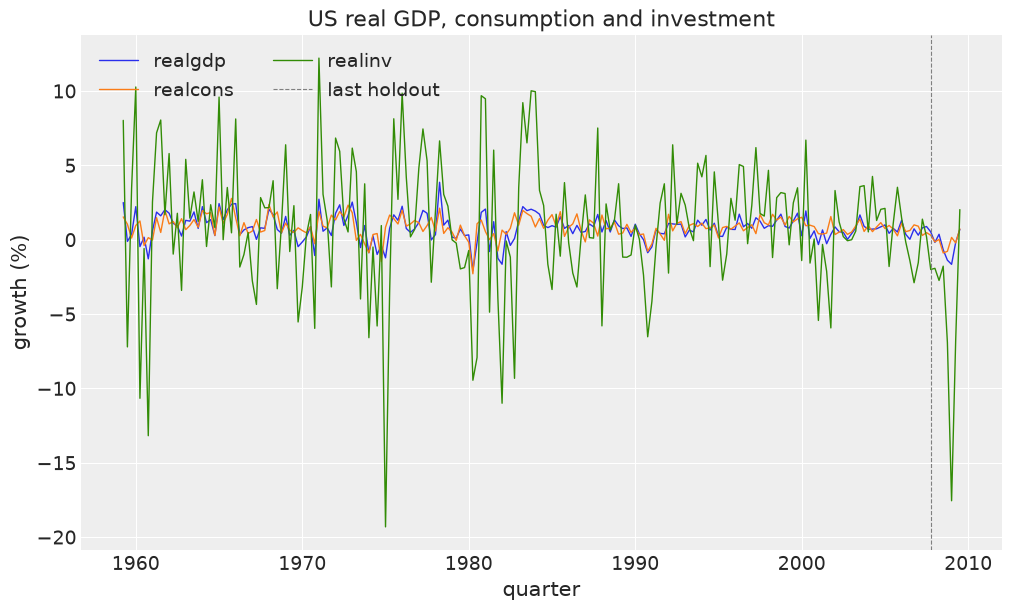

In [3]:
fig, ax = plt.subplots()
for name, color in zip(growth["series"].values, ("C0", "C1", "C2"), strict=True):
    ax.plot(growth["time"].values, growth.sel(series=name), color=color, lw=1, label=name)
ax.axvline(growth["time"].values[-HOLDOUT], color="gray", ls="--", lw=0.8, label="last holdout")
ax.legend(loc="upper left", ncol=2)
ax.set(title="US real GDP, consumption and investment", xlabel="quarter", ylabel="growth (%)")
plt.show()

## A stationary Minnesota prior

Impulso's default Minnesota prior puts mean 1 on each series' own first lag: a random
walk. That centre is for levels. These series are growth rates, so the own-lag mean is 0.
Tightness, lag decay and cross-lag shrinkage stay at the documented defaults (`0.1`,
`"harmonic"`, `0.5`).

Two lags match the numpyro-forecast example. The specification is an Impulso `VAR`, not a
`ForecastingModel`: Impulso forecasts by iterating the posterior coefficient draws in
NumPy (`FittedVAR.forecast`), and that path is not a `forecast` random variable
`pm.sample_posterior_predictive` can replay.

In [4]:
spec = VAR(lags=2, prior=MinnesotaPrior(own_lag_mean=0.0))
spec

VAR(lags=2, max_lags=None, prior=MinnesotaPrior(tightness=0.1, decay='harmonic', cross_shrinkage=0.5, own_lag_mean=0.0), volatility='constant', exog_prior_scale=100.0, error_dist='gaussian')

## Adapter

`backtest` constructs `forecaster_cls(model, train, covariates, random_seed=..., **options)`
and reads `forecast(...)["predictions"]["forecast"]` with dims
`(chain, draw, time_future, series)`. The adapter below fits the training slice, draws
Impulso's density forecast (parameter uncertainty plus future shocks) over the quarters
that extend past the training window, and relabels Impulso's `step` / `variable` axes
onto those dates. The library's `prediction_samples` and `thin_draws` do the container
handling and the `num_samples` subsampling. The covariates are the horizon carrier only:
`backtest` passes `None` and builds them with `null_covariates`.

In [5]:
class ImpulsoForecaster:
    """Fit an Impulso VAR on one window and forecast with ``FittedVAR.forecast``."""

    def __init__(
        self,
        model: VAR,
        data: xr.DataArray,
        covariates: xr.DataArray,
        *,
        random_seed: int,
        draws: int,
        tune: int,
        chains: int,
    ) -> None:
        del covariates  # horizon carrier only; the fit uses the training slice
        if not isinstance(model, VAR):
            msg = f"expected an impulso.VAR specification, got {type(model).__name__}"
            raise TypeError(msg)
        self.num_train = data.sizes["time"]
        frame = data.to_pandas()
        sampler = NUTSSampler(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=1,
            random_seed=int(random_seed),
            nuts_sampler="pymc",
            progressbar=False,
        )
        self.fitted = model.fit(VARData.from_df(frame, endog=list(frame.columns)), sampler=sampler)

    def forecast(self, covariates: xr.DataArray, num_samples: int, random_seed: int) -> xr.DataTree:
        future_time = covariates["time"].values[self.num_train :]
        result = self.fitted.forecast(steps=len(future_time), seed=int(random_seed))
        draws = thin_draws(prediction_samples(result.idata), num_samples, random_seed)["forecast"]
        forecast = draws.rename(step="time_future", variable="series").assign_coords(
            time_future=future_time
        )
        return xr.DataTree.from_dict({"predictions": forecast.to_dataset()})

    def predict_in_sample(self, num_samples: int, random_seed: int) -> xr.DataTree:
        del num_samples, random_seed
        msg = "ImpulsoForecaster scores out-of-sample forecasts only (backtest eval_train=False)"
        raise NotImplementedError(msg)

## One holdout

Fit on every quarter but the last eight (2007Q4–2009Q3), then forecast those eight. They
run through the 2008–09 collapse, so coverage on this split is not a calibration check.
The summary is the reduced-form posterior: `B` is lag-major, all series at lag 1, then all
series at lag 2.

In [6]:
train = growth.isel(time=slice(None, -HOLDOUT))
truth = growth.isel(time=slice(-HOLDOUT, None)).rename(time="time_future")
covariates = null_covariates(growth["time"].values)

forecaster = ImpulsoForecaster(
    spec, train, covariates, random_seed=SEED, draws=DRAWS, tune=TUNE, chains=CHAINS
)
idata = forecaster.fitted.idata
posterior_summary = az.summary(idata, var_names=["B", "intercept"])
print("divergences:", int(idata["sample_stats"]["diverging"].sum()))
print("max r_hat:", float(posterior_summary["r_hat"].max()))
posterior_summary

divergences: 0
max r_hat: 1.002215251987915


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"B[realgdp, L1.realgdp]",0.086,0.053,0.0041,0.17,3611,3222,1.00,0.00088,0.00075
"B[realgdp, L1.realcons]",0.072,0.048,-0.0053,0.15,3033,3041,1.00,0.00087,0.00072
"B[realgdp, L1.realinv]",-0,0.0075,-0.012,0.012,4047,3093,1.00,0.00012,0.00012
"B[realgdp, L2.realgdp]",0.039,0.035,-0.019,0.096,3394,2859,1.00,0.00061,0.00056
"B[realgdp, L2.realcons]",0.0281,0.028,-0.016,0.072,4724,3081,1.00,0.00041,0.00044
"B[realgdp, L2.realinv]",-0.0006,0.0042,-0.0073,0.006,4465,3504,1.00,6.2e-05,5.7e-05
"B[realcons, L1.realgdp]",0.032,0.0336,-0.022,0.084,4353,3375,1.00,0.00051,0.00049
"B[realcons, L1.realcons]",0.066,0.054,-0.021,0.15,3416,2979,1.00,0.00092,0.0008
"B[realcons, L1.realinv]",0.0064,0.0062,-0.0035,0.016,4753,3107,1.00,8.9e-05,0.00011
"B[realcons, L2.realgdp]",0.0062,0.0183,-0.024,0.035,4295,2958,1.00,0.00028,0.00029


In [7]:
forecast = prediction_samples(
    forecaster.forecast(covariates, num_samples=NUM_SAMPLES, random_seed=SEED + 1)
)["forecast"]
assert forecast.dims == ("chain", "draw", "time_future", "series")
pd.Series(evaluate_forecast(forecast, truth))

mae         2.687665
rmse        4.741323
crps        2.019438
coverage    0.666667
dtype: float64

## Plot helpers

One axis per series, the observed growth in black, and a forecast drawn as its median with
central 50% and 90% bands. The 90% band is the interval `eval_coverage` scores.

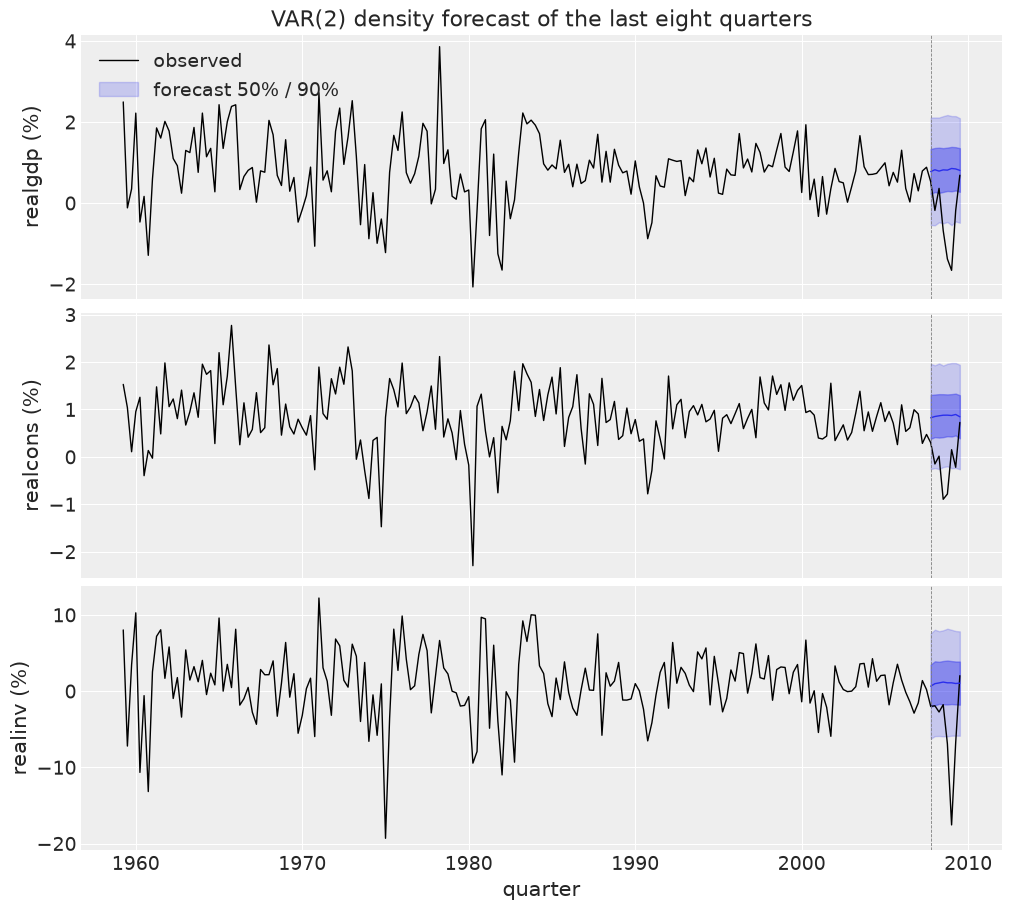

In [8]:
def plot_series_panels(observed: xr.DataArray, *, title: str) -> tuple[Figure, np.ndarray]:
    """One axis per series with the observed growth in black; returns ``(fig, axes)``."""
    fig, axes = plt.subplots(observed.sizes["series"], 1, figsize=(10, 9), sharex=True)
    for ax, name in zip(axes, observed["series"].values, strict=True):
        series = observed.sel(series=name)
        ax.plot(series["time"].values, series, color="black", lw=1, label="observed")
        ax.set(ylabel=f"{name} (%)")
    axes[0].set_title(title)
    axes[-1].set(xlabel="quarter")
    return fig, axes


def plot_forecast_band(
    ax: Axes, samples: xr.DataArray, *, color: str, label: str | None = None
) -> None:
    """Median and central 50% / 90% intervals of ``(chain, draw, time_future)`` samples."""
    q = samples.quantile([0.05, 0.25, 0.5, 0.75, 0.95], dim=("chain", "draw"))
    time = samples["time_future"].values
    lo, hi = q.sel(quantile=0.05), q.sel(quantile=0.95)
    ax.fill_between(time, lo, hi, color=color, alpha=0.2, label=label)
    ax.fill_between(time, q.sel(quantile=0.25), q.sel(quantile=0.75), color=color, alpha=0.4)
    ax.plot(time, q.sel(quantile=0.5), color=color, lw=1)
    ax.axvline(time[0], color="gray", ls="--", lw=0.6)


fig, axes = plot_series_panels(growth, title="VAR(2) density forecast of the last eight quarters")
for ax, name in zip(axes, growth["series"].values, strict=True):
    plot_forecast_band(ax, forecast.sel(series=name), color="C0", label="forecast 50% / 90%")
axes[0].legend(loc="upper left")
plt.show()

## Expanding-window backtest

Each fold refits on its own history and forecasts the next eight quarters; the full run
scores the last four folds (2001Q4 onwards) and the smoke check one. Besides the default
metrics, a CRPS per series goes in as an extra metric so the fold table and the plot below
can separate GDP from investment. Scores include the shock draws, so a tight band here
would mean the adapter had dropped them.

In [9]:
def series_crps(name: str) -> Metric:
    """CRPS restricted to one series, for ``backtest(metrics=...)``."""
    return lambda pred, truth: eval_crps(pred.sel(series=name), truth.sel(series=name))


series_names = list(growth["series"].values)
results = backtest(
    growth,
    None,
    spec,
    forecaster_cls=ImpulsoForecaster,
    forecaster_options={"draws": DRAWS, "tune": TUNE, "chains": CHAINS},
    metrics={**DEFAULT_METRICS, **{f"crps_{name}": series_crps(name) for name in series_names}},
    min_train_window=growth.sizes["time"] - FOLDS * HOLDOUT,
    test_window=HOLDOUT,
    stride=HOLDOUT,
    num_samples=NUM_SAMPLES,
    keep_predictions=True,
    random_seed=SEED + 2,
)
scores = results_to_dataframe(results)
scores

,t0,t1,t2,num_samples,train_walltime,test_walltime,mae,rmse,crps,coverage,crps_realgdp,crps_realcons,crps_realinv
0,0,170,178,4000,5.610310,0.006732,0.906577,1.597082,0.729789,1.000000,0.303543,0.281307,1.604517
1,0,178,186,4000,5.894161,0.006808,0.557351,1.018951,0.562119,1.000000,0.210542,0.189987,1.285828
2,0,186,194,4000,6.258216,0.007139,0.822877,1.299020,0.647249,1.000000,0.274584,0.238859,1.428305
3,0,194,202,4000,6.173975,0.006879,2.659651,4.712398,1.997245,0.666667,0.841235,0.690695,4.459805


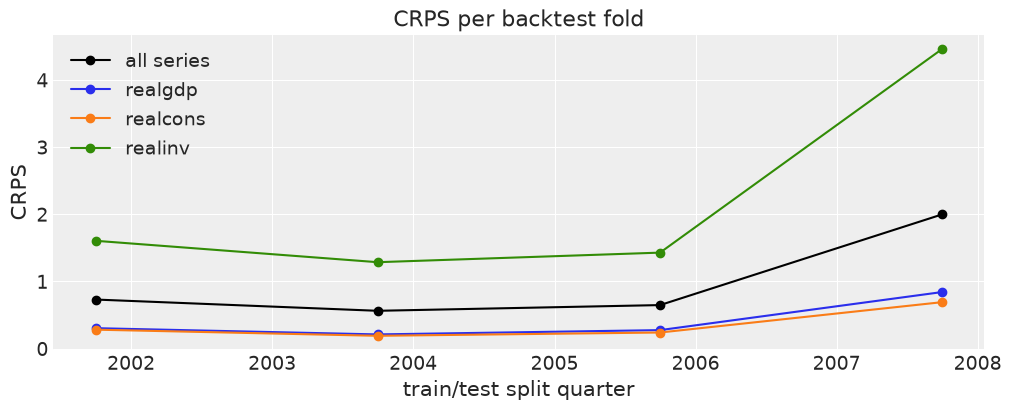

In [10]:
split_quarters = growth["time"].values[scores["t1"].to_numpy()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(split_quarters, scores["crps"], "o-", color="black", label="all series")
for name, color in zip(series_names, ("C0", "C1", "C2"), strict=True):
    ax.plot(split_quarters, scores[f"crps_{name}"], "o-", color=color, label=name)
ax.legend()
ax.set(xlabel="train/test split quarter", ylabel="CRPS", title="CRPS per backtest fold")
plt.show()

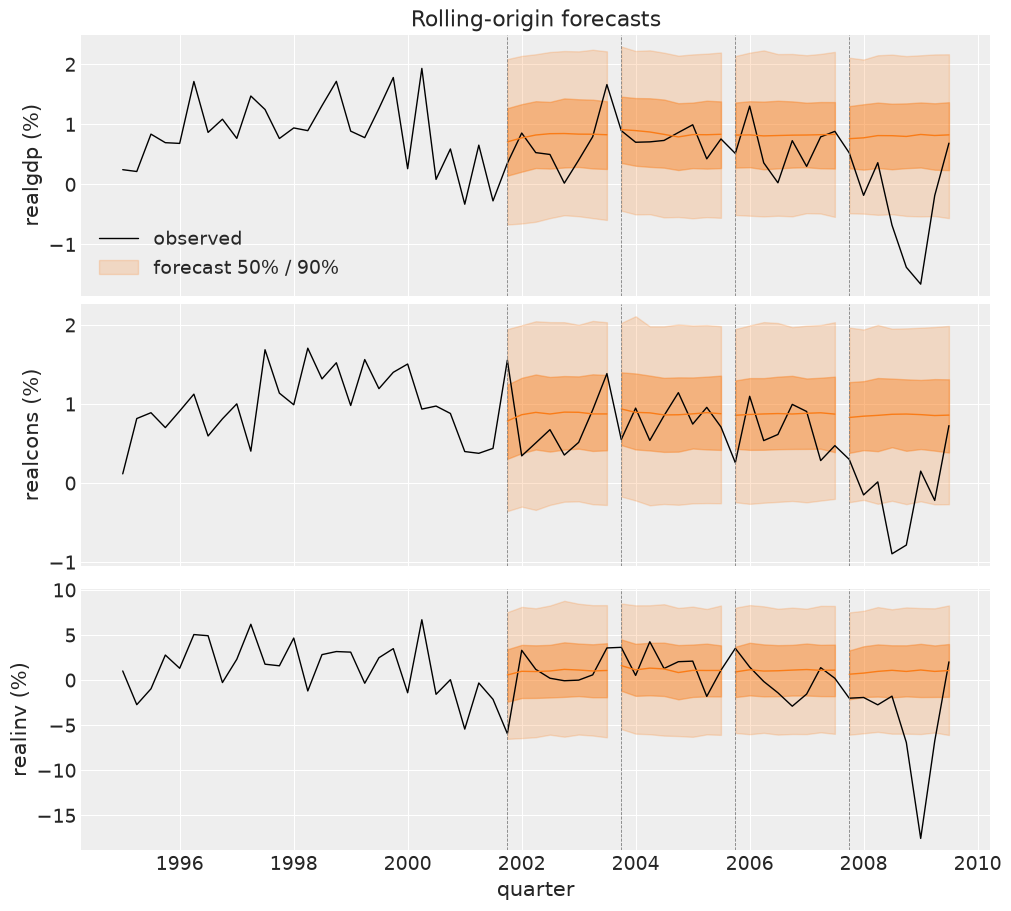

In [11]:
recent = growth.sel(time=slice("1995", None))
fig, axes = plot_series_panels(recent, title="Rolling-origin forecasts")
for result in results:
    label = "forecast 50% / 90%" if result is results[0] else None
    for ax, name in zip(axes, series_names, strict=True):
        plot_forecast_band(ax, result.prediction.sel(series=name), color="C1", label=label)
axes[0].legend(loc="lower left")
plt.show()

## What to inspect

Read the own-lag coefficients against the prior mean of 0, and check divergences and
`r_hat` before treating the bands as calibrated. CRPS on eight quarters is noisy; the
per-series lines show that investment, not GDP, is the hard series, and the last fold shows
what a stationary VAR does when the holdout is a recession. This notebook does not identify
shocks. For impulse responses, use Impulso's identification API on `forecaster.fitted`.